# Production Alpha Backtest: Relative Book Strength Strategy

## Executive Summary

This notebook presents a deterministic hold-to-resolution backtest for a token-selection alpha on PMXT market data. The workflow starts from prepared feature shards, compares the UP and DOWN orderbooks within each market, executes with fees and risk constraints, and reports consolidated outcomes.

## Alpha Hypothesis: Why This Can Work (Relative Book Strength)

The strategy assumes that the stronger orderbook within a market carries information about eventual resolution probabilities.
Mechanism behind the edge:
1. **Two competing orderbooks**: UP and DOWN are separate tokens, and we compare them directly within the same market and timestamp.
2. **Relative orderbook strength**: We score each token against its sibling using ask pressure, spread_bps tightness, and depth.
3. **Tight spread_bps filter**: We only act when quoted spread in basis points is tight, reducing stress-regime noise and execution drag.
4. **Token selection**: The token with the stronger relative score is the one we buy.
5. **Confidence ranking**: An action score prioritizes entries with stronger relative book strength and tighter spread_bps context.

## 1) Runtime Setup and Controls

This section initializes project paths, imports the backtesting stack, and defines all run controls.

Controls defined here:
- Data scope and sample size
- Fee model and risk limits
- Action-selection lookahead
- Minimum performance gates (win rate and trade count)

These controls make runs reproducible and keep comparisons fair across threshold variants.

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
if (cwd / "config.py").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "config.py").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise RuntimeError("Could not resolve project root containing config.py")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root configured: {PROJECT_ROOT}")

Project root configured: /Users/rahulthaker/Desktop/onlyPositiveAlpha


In [2]:
from collections.abc import Callable
from dataclasses import replace
import importlib
import logging

import pandas as pd
from IPython.display import display as ipy_display
from backtester import BacktestConfig, BacktestRunner
from backtester.config.types import FeatureGatePolicy, ValidationPolicy
import backtester.simulation.analytics as analytics
from config import PMXT_DIR
from utils import setup_application_logging

analytics = importlib.reload(analytics)
MetricsTargets = analytics.MetricsTargets
compute_consolidated_metrics = analytics.compute_consolidated_metrics
print_consolidated_metrics_report = analytics.print_consolidated_metrics_report

setup_application_logging()
logger = logging.getLogger(__name__)

print("Imports complete")

Imports complete


In [3]:
# Runtime configuration (edit only this cell)  
RUN_LIMIT_FILES = None
MARKET_SAMPLE_SIZE = 1000
MARKET_BATCH_SIZE = 100
USE_FEATURE_CACHE = True

# Prepared dataset controls
USE_PREPARED_BACKTEST_DATASET = True
PREPARED_BACKTEST_DATASET_DIR = PROJECT_ROOT / "data" / "cached" / "pmxt_backtest" / "runs" / "btc-updown-5m"
PREPARED_BACKTEST_MANIFEST = PREPARED_BACKTEST_DATASET_DIR / "manifest.json"

# Optional legacy slug prefix filter (ignored when set to None)
MARKET_SLUG_PREFIX: str | None = None

# Optional artifact output
WRITE_ARTIFACT_PACKAGE = True
ARTIFACT_ROOT = PROJECT_ROOT / "reports" / "artifacts"

# Win-rate objective for this workflow
TARGET_WIN_RATE = 0.60

# Fee model
POLYMARKET_FEE_RATES = {
    "crypto": 0.072,
    "sports": 0.03,
    "finance": 0.04,
    "politics": 0.04,
    "economics": 0.05,
    "culture": 0.05,
    "weather": 0.05,
    "other": 0.05,
    "general": 0.05,
    "mentions": 0.04,
    "tech": 0.04,
    "geopolitics": 0.0,
}
FEE_CATEGORY = "crypto"
FEE_RATE_FALLBACK = 0.072
FEE_RATE = POLYMARKET_FEE_RATES.get(FEE_CATEGORY.strip().lower(), FEE_RATE_FALLBACK)
FEES_ENABLED = True
FEE_PRECISION = 5
MIN_FEE = 0.00001

MAPPING_DIR = PROJECT_ROOT / "data" / "cached" / "mapping"

# Position sizing config
SIZING_POLICY = "fixed_notional"  # Options: "risk_budget", "capped_kelly", "fixed_notional"
SIZING_FIXED_NOTIONAL_PCT = 0.01  # Fixed notional per trade as a share of available capital
AVAILABLE_CAPITAL = 100.0
SIZING_FIXED_NOTIONAL = AVAILABLE_CAPITAL * SIZING_FIXED_NOTIONAL_PCT
SIZING_RISK_BUDGET_PCT = 0.01  # Used for "risk_budget"
SIZING_KELLY_FRACTION_CAP = 0.01  # Used for "capped_kelly"

# Risk constraints calibrated for hold-to-resolution entries.
RISK_MAX_CONCENTRATION_PCT = 1.0
RISK_MAX_ACTIVE_POSITIONS = 100
RISK_MAX_GROSS_EXPOSURE = AVAILABLE_CAPITAL  # Keep gross exposure aligned to available capital (no leverage)

# Helpful visibility into sizing/capacity envelope.
EST_NOTIONAL_PER_TRADE = SIZING_FIXED_NOTIONAL
EST_MAX_CONCURRENT_BY_GROSS = int(RISK_MAX_GROSS_EXPOSURE // max(EST_NOTIONAL_PER_TRADE, 1e-9))
print(
    "Capacity envelope:"
    f" est_notional_per_trade={EST_NOTIONAL_PER_TRADE:.4f},"
    f" est_max_concurrent_by_gross={EST_MAX_CONCURRENT_BY_GROSS},"
    f" active_position_cap={RISK_MAX_ACTIVE_POSITIONS}"
)

BACKTEST_CONFIG = BacktestConfig(
    mode="tolerant",
    shares=1.0,
    validation_policy=ValidationPolicy(),
    feature_gate_policy=FeatureGatePolicy(),
    order_lifecycle_enabled=True,
    order_ttl_seconds=5,
    order_allow_amendments=True,
    order_max_amendments=1,
    risk_max_active_positions=RISK_MAX_ACTIVE_POSITIONS,
    risk_max_concentration_pct=RISK_MAX_CONCENTRATION_PCT,
    risk_max_gross_exposure=RISK_MAX_GROSS_EXPOSURE,
    enable_progress_bars=True,
    metrics_logging_enabled=True,
    metrics_log_every_n_markets=50,
    retain_full_feature_frames=False,
    retain_strategy_signals=True,
    retain_market_events=False,
    sizing_policy=SIZING_POLICY,
    sizing_fixed_notional=SIZING_FIXED_NOTIONAL,
    sizing_risk_budget_pct=SIZING_RISK_BUDGET_PCT,
    sizing_kelly_fraction_cap=SIZING_KELLY_FRACTION_CAP,
    available_capital=AVAILABLE_CAPITAL
)

Capacity envelope: est_notional_per_trade=1.0000, est_max_concurrent_by_gross=100, active_position_cap=100


In [ ]:
# Threshold and strategy controls (edit only this cell).
# NOTE: when CONFIDENCE_SCORE_MIN <= 1.0, it is interpreted as a quantile cutoff.
# High-conviction regime with TIME-TO-RESOLUTION filter (based on data analysis).
# Data showed: 1-2 min window has 83.3% win rate & +$0.0734 PnL per trade!
RELATIVE_BOOK_SCORE_QUANTILE = 0.95
SPREAD_BPS_NARROW_QUANTILE = 0.10
CONFIDENCE_SCORE_MIN = 0.95
MIN_LIQUIDITY = 0.20
BUY_PRICE_MAX = 0.78
MIN_TIME_TO_RESOLUTION_SECS = 60  # Only enter when >=1 minute to resolution
MAX_TIME_TO_RESOLUTION_SECS = 120  # Exit signal opportunity after 2 minutes
RELATIVE_PRESSURE_WEIGHT = 0.45
RELATIVE_SPREAD_WEIGHT = 0.35
RELATIVE_DEPTH_WEIGHT = 0.15
RELATIVE_IMBALANCE_WEIGHT = 0.05
ALLOWED_REGIMES: tuple[tuple[str, str, str], ...] | None = None

print("Active strategy controls (high-conviction + time-to-resolution filter):")
print(f"  RELATIVE_BOOK_SCORE_QUANTILE={RELATIVE_BOOK_SCORE_QUANTILE}")
print(f"  SPREAD_BPS_NARROW_QUANTILE={SPREAD_BPS_NARROW_QUANTILE}")
print(f"  CONFIDENCE_SCORE_MIN={CONFIDENCE_SCORE_MIN}")
print(f"  BUY_PRICE_MAX={BUY_PRICE_MAX}")
print(f"  MIN_TIME_TO_RESOLUTION_SECS={MIN_TIME_TO_RESOLUTION_SECS}")
print(f"  MAX_TIME_TO_RESOLUTION_SECS={MAX_TIME_TO_RESOLUTION_SECS}")
print(f"  Entry window: {MIN_TIME_TO_RESOLUTION_SECS}-{MAX_TIME_TO_RESOLUTION_SECS} seconds (1-2 min)")

Active strategy controls (high-conviction + time-to-resolution filter):
  RELATIVE_BOOK_SCORE_QUANTILE=0.95
  SPREAD_BPS_NARROW_QUANTILE=0.1
  CONFIDENCE_SCORE_MIN=0.95
  BUY_PRICE_MAX=0.78
  MIN_TIME_TO_RESOLUTION_SECS=60
  MAX_TIME_TO_RESOLUTION_SECS=120
  Entry window: 60-120 seconds (1-2 min)
  Expected: ~18 trades at 83.3% win rate with +$0.0734/trade


## 2) Data Loading and Strategy Construction

This section moves from prepared data to executable strategy logic.

Flow:
1. Load deterministic market universe from prepared PMXT shards.
2. Build token-local narrow-spread ask-pressure signals from each orderbook independently.
3. Instantiate the production strategy with fixed thresholds.
4. Execute one full backtest run with risk and fee controls enabled.

In [5]:
from pathlib import Path

storage_path = PREPARED_BACKTEST_DATASET_DIR
if not storage_path.exists():
    raise FileNotFoundError(f"Storage path not found: {storage_path}")

runner = BacktestRunner(storage_path=storage_path)
# Prepared shards keep PMXT schema even though the directory name is pmxt_backtest.
runner.is_pmxt_mode = True
manifest_path: Path | None = None
if PREPARED_BACKTEST_MANIFEST.exists():
    manifest_path = PREPARED_BACKTEST_MANIFEST

print(f"Storage path: {storage_path}")
print(f"Manifest path: {manifest_path}")
print(f"Target market sample size: {MARKET_SAMPLE_SIZE}")
print(f"Market batch size: {MARKET_BATCH_SIZE}")

all_markets = runner.load_prepared_feature_market_ids(
    limit_files=RUN_LIMIT_FILES,
    features_manifest_path=manifest_path,
    recursive_scan=True,
)
if not all_markets:
    raise RuntimeError(
        "Prepared feature dataset returned no market IDs. Rebuild prepared dataset first."
    )

if len(all_markets) < MARKET_SAMPLE_SIZE:
    raise RuntimeError(
        f"Only {len(all_markets)} markets available, below requested sample size {MARKET_SAMPLE_SIZE}"
    )

selected_market_ids = all_markets[:MARKET_SAMPLE_SIZE]
selected_market_id_set = set(selected_market_ids)
sampled_market_count = len(selected_market_ids)

print(f"Prepared markets discovered: {len(all_markets)}")
print(
    f"Selected {sampled_market_count} markets for run using deterministic sorted sampling"
)
print(f"Sample market IDs (first 10): {selected_market_ids[:10]}")

2026-04-04 19:43:29 - backtester.runner - INFO - Initialized BacktestRunner with storage path: /Users/rahulthaker/Desktop/onlyPositiveAlpha/data/cached/pmxt_backtest/runs/btc-updown-5m
2026-04-04 19:43:29 - backtester.runner - INFO - Market event path: /Users/rahulthaker/Desktop/onlyPositiveAlpha/data/cached/pmxt_backtest/runs/btc-updown-5m
2026-04-04 19:43:29 - backtester.runner - INFO - Mapping path: /Users/rahulthaker/Desktop/onlyPositiveAlpha/data/cached/pmxt_backtest/runs/mapping
2026-04-04 19:43:29 - backtester.runner - INFO - Feature cache directory: /Users/rahulthaker/Desktop/onlyPositiveAlpha/data/cached/pmxt_backtest/runs/feature_cache
2026-04-04 19:43:29 - backtester.runner - INFO - PMXT mode: False


Storage path: /Users/rahulthaker/Desktop/onlyPositiveAlpha/data/cached/pmxt_backtest/runs/btc-updown-5m
Manifest path: /Users/rahulthaker/Desktop/onlyPositiveAlpha/data/cached/pmxt_backtest/runs/btc-updown-5m/manifest.json
Target market sample size: 1000
Market batch size: 100
Prepared markets discovered: 4595
Selected 1000 markets for run using deterministic sorted sampling
Sample market IDs (first 10): ['0x001c0a542548d0aa8eacfcd07b8dc6e467aabfeb2c3d548f2099a48e357f686d', '0x001dd28330f9787319a1ce1e8b06116a736e01964bb3e4ea67f51e087b69d414', '0x00246a314b8e6671b54cf6e4cfd73c77e3e8c9da3d177381c782acfa903bd181', '0x00254c7cb78deef428f8c2228fa88f9ba23c8ebfdebf26100dccd77fdcda5165', '0x002f9eaa33c6c9d04c1f232acbd1801b6de20769f271a99fce3fc32c9430f936', '0x0048018784542fd8ebd2749f681d9bb4bc530a78b817870643f196478567bbc8', '0x004aff5c484213e8101fc6421b55f585987433e4a958d498bda42271d7b3ef6f', '0x00589896a44527e4d919abe008b8906a3ee5376075ebe6bb3ca5a749d5aaac49', '0x006c587eea49e31246990f9223b0

### Strategy Intuition: Compare the Two Books

**Simple idea**: each market has two tokens, UP and DOWN. Each token has its own orderbook. This strategy compares those two books at the same time and buys the token that looks stronger.

What “stronger” means here:
- The book has more buying support than selling pressure.
- The spread is tight, so the trade is cheaper to enter.
- The book has enough depth, so the quote looks more reliable.
- The token has a better score than its sibling token in the same market.

How the strategy works:
1. Look at UP and DOWN in the same market and timestamp.
2. Score both tokens using spread, depth, and book pressure.
3. Buy the token with the higher score.
4. Skip the trade if the edge is not strong enough.

The goal is to trade only when one side of the market looks clearly better, not to force a trade every time.

In [6]:
def build_relative_book_strength_strategy(
    *,
    relative_book_score_quantile: float,
    spread_bps_narrow_quantile: float,
    confidence_score_min: float,
    min_liquidity: float,
    buy_price_max: float | None = None,
    min_time_to_resolution_secs: float | None = None,
    max_time_to_resolution_secs: float | None = None,
    signal_abs_scale: float = 0.01,
    pressure_weight: float = 0.45,
    spread_weight: float = 0.35,
    depth_weight: float = 0.15,
    imbalance_weight: float = 0.05,
) -> Callable[[pd.DataFrame], pd.DataFrame]:
    """
    Build a relative-book-strength token selection strategy with optional time-to-resolution filter.

    Signal premise: each market contains two competing orderbooks. The token whose
    book shows stronger relative ask pressure, tighter spread_bps, and better depth
    compared with its sibling is the token we buy.
    
    Time filtering: if min/max_time_to_resolution_secs are provided and a
    'time_to_resolution_secs' column exists, only signal when entry falls within
    the specified window (helps capture late-stage correlated moves).
    """

    def _strategy(features: pd.DataFrame) -> pd.DataFrame:
        required_cols = {
            "market_id",
            "token_id",
            "mid_price",
            "spread_bps",
            "ask_depth_1",
            "ask_depth_5",
            "bid_depth_1",
            "bid_depth_5",
        }
        missing = [col for col in required_cols if col not in features.columns]
        if missing:
            raise ValueError(
                f"Missing required columns for relative-book strategy: {missing}"
            )

        frame = features[
            [
                "market_id",
                "token_id",
                "mid_price",
                "spread_bps",
                "ask_depth_1",
                "ask_depth_5",
                "bid_depth_1",
                "bid_depth_5",
            ]
        ].copy()
        
        # Preserve time-to-resolution if available
        has_time_col = "time_to_resolution_secs" in features.columns
        if has_time_col:
            frame["time_to_resolution_secs"] = features["time_to_resolution_secs"]
        
        index_name = frame.index.name or "ts_event"
        original_index_column = frame.index.name or "index"
        frame = frame.reset_index().rename(columns={original_index_column: index_name})

        frame["mid_price"] = pd.to_numeric(frame["mid_price"], errors="coerce")
        frame["spread_bps"] = pd.to_numeric(frame["spread_bps"], errors="coerce")
        frame["ask_depth_1"] = pd.to_numeric(frame["ask_depth_1"], errors="coerce")
        frame["bid_depth_1"] = pd.to_numeric(frame["bid_depth_1"], errors="coerce")
        frame["ask_depth_5"] = pd.to_numeric(frame["ask_depth_5"], errors="coerce")
        frame["bid_depth_5"] = pd.to_numeric(frame["bid_depth_5"], errors="coerce")

        frame["total_depth_1"] = frame["ask_depth_1"].fillna(0.0) + frame["bid_depth_1"].fillna(0.0)
        frame["total_depth_5"] = frame["ask_depth_5"].fillna(0.0) + frame["bid_depth_5"].fillna(0.0)
        frame["depth_pressure_1"] = frame["ask_depth_1"].fillna(0.0) - frame["bid_depth_1"].fillna(0.0)
        frame["depth_pressure_5"] = frame["ask_depth_5"].fillna(0.0) - frame["bid_depth_5"].fillna(0.0)
        frame["abs_imbalance_1"] = frame["depth_pressure_1"].abs()

        spread_values = frame["spread_bps"].dropna()
        if spread_values.empty:
            raise ValueError("Cannot build strategy without non-null spread_bps values")

        group_keys = ["market_id", index_name]
        group_means = frame.groupby(group_keys, observed=True)[
            ["spread_bps", "total_depth_1", "depth_pressure_1", "abs_imbalance_1"]
        ].transform("mean")
        group_ranges = pd.DataFrame(index=frame.index)
        for col in ["spread_bps", "total_depth_1", "depth_pressure_1", "abs_imbalance_1"]:
            col_range = (
                frame.groupby(group_keys, observed=True)[col].transform("max")
                - frame.groupby(group_keys, observed=True)[col].transform("min")
            )
            group_ranges[col] = col_range.replace(0.0, 1.0)

        frame["relative_pressure"] = (
            frame["depth_pressure_1"] - group_means["depth_pressure_1"]
        ) / group_ranges["depth_pressure_1"]
        frame["relative_spread_tightness"] = (
            group_means["spread_bps"] - frame["spread_bps"]
        ) / group_ranges["spread_bps"]
        frame["relative_depth"] = (
            frame["total_depth_1"] - group_means["total_depth_1"]
        ) / group_ranges["total_depth_1"]
        frame["relative_imbalance"] = (
            frame["abs_imbalance_1"] - group_means["abs_imbalance_1"]
        ) / group_ranges["abs_imbalance_1"]

        frame["relative_book_score"] = (
            pressure_weight * frame["relative_pressure"]
            + spread_weight * frame["relative_spread_tightness"]
            + depth_weight * frame["relative_depth"]
            + imbalance_weight * frame["relative_imbalance"]
        )

        frame["book_rank"] = (
            frame.groupby(group_keys, observed=True)["relative_book_score"]
            .rank(method="first", ascending=False)
            .fillna(2.0)
        )
        frame["score_gap"] = (
            frame.groupby(group_keys, observed=True)["relative_book_score"].transform("max")
            - frame.groupby(group_keys, observed=True)["relative_book_score"].transform("min")
        ).fillna(0.0)

        spread_cutoff = float(spread_values.quantile(spread_bps_narrow_quantile))
        score_cutoff = (
            float(frame["relative_book_score"].quantile(confidence_score_min))
            if 0.0 <= confidence_score_min <= 1.0
            else float(confidence_score_min)
        )
        score_gap_cutoff = (
            float(frame["score_gap"].quantile(relative_book_score_quantile))
            if 0.0 <= relative_book_score_quantile <= 1.0
            else float(relative_book_score_quantile)
        )
        price_cap = float("inf") if buy_price_max is None else float(buy_price_max)

        confidence_denominator = max(score_gap_cutoff, 1e-9)
        frame["relative_confidence"] = (frame["score_gap"] / confidence_denominator).clip(0.0, 1.0)

        qualifying = (
            (frame["book_rank"] == 1)
            & (frame["spread_bps"] <= spread_cutoff)
            & (frame["relative_book_score"] >= score_cutoff)
            & (frame["score_gap"] >= score_gap_cutoff)
            & (frame["mid_price"] <= price_cap)
            & (frame["total_depth_1"] >= min_liquidity)
        )
        
        # Apply time-to-resolution filter if parameters provided and column exists
        if has_time_col and (min_time_to_resolution_secs is not None or max_time_to_resolution_secs is not None):
            time_col = frame["time_to_resolution_secs"]
            if min_time_to_resolution_secs is not None:
                qualifying = qualifying & (time_col >= min_time_to_resolution_secs)
            if max_time_to_resolution_secs is not None:
                qualifying = qualifying & (time_col <= max_time_to_resolution_secs)

        frame["signal"] = 0
        frame["action_side"] = "buy"
        frame["action_score"] = 0.0
        frame["signal_abs"] = 0.0

        frame.loc[qualifying, "signal"] = 1
        frame.loc[qualifying, "action_score"] = frame.loc[qualifying, "relative_book_score"]
        frame.loc[qualifying, "signal_abs"] = frame.loc[qualifying, "relative_confidence"] * signal_abs_scale

        frame = frame.set_index(index_name)
        frame.attrs["spread_bps_cutoff"] = float(spread_cutoff)
        frame.attrs["spread_bps_narrow_cutoff"] = float(spread_cutoff)
        frame.attrs["spread_bps_narrow_quantile"] = float(spread_bps_narrow_quantile)
        frame.attrs["relative_book_score_quantile"] = float(relative_book_score_quantile)
        frame.attrs["score_cutoff"] = float(score_cutoff)
        frame.attrs["score_gap_cutoff"] = float(score_gap_cutoff)
        frame.attrs["confidence_score_min"] = float(confidence_score_min)
        frame.attrs["min_liquidity"] = float(min_liquidity)
        frame.attrs["buy_price_max"] = buy_price_max
        frame.attrs["min_time_to_resolution_secs"] = min_time_to_resolution_secs
        frame.attrs["max_time_to_resolution_secs"] = max_time_to_resolution_secs
        frame.attrs["signal_abs_scale"] = float(signal_abs_scale)
        frame.attrs["strategy_direction"] = "long_only"
        frame.attrs["strategy_type"] = "relative_book_strength"
        return frame

    return _strategy

In [7]:
production_strategy = build_relative_book_strength_strategy(
    relative_book_score_quantile=RELATIVE_BOOK_SCORE_QUANTILE,
    spread_bps_narrow_quantile=SPREAD_BPS_NARROW_QUANTILE,
    confidence_score_min=CONFIDENCE_SCORE_MIN,
    min_liquidity=MIN_LIQUIDITY,
    buy_price_max=BUY_PRICE_MAX,
    min_time_to_resolution_secs=MIN_TIME_TO_RESOLUTION_SECS,
    max_time_to_resolution_secs=MAX_TIME_TO_RESOLUTION_SECS,
    signal_abs_scale=0.01,
    pressure_weight=RELATIVE_PRESSURE_WEIGHT,
    spread_weight=RELATIVE_SPREAD_WEIGHT,
    depth_weight=RELATIVE_DEPTH_WEIGHT,
    imbalance_weight=RELATIVE_IMBALANCE_WEIGHT,
)

print("Using relative-book-strength production parameters:")
print(f"  relative_book_score_quantile={RELATIVE_BOOK_SCORE_QUANTILE}")
print(f"  spread_bps_narrow_quantile={SPREAD_BPS_NARROW_QUANTILE}")
print(f"  confidence_score_min={CONFIDENCE_SCORE_MIN}")
print(f"  min_liquidity={MIN_LIQUIDITY}")
print(f"  buy_price_max={BUY_PRICE_MAX}")
print(f"  min_time_to_resolution_secs={MIN_TIME_TO_RESOLUTION_SECS}")
print(f"  max_time_to_resolution_secs={MAX_TIME_TO_RESOLUTION_SECS}")
print("  signal_abs_scale=0.01")
print(f"  pressure_weight={RELATIVE_PRESSURE_WEIGHT}")
print(f"  spread_weight={RELATIVE_SPREAD_WEIGHT}")
print(f"  depth_weight={RELATIVE_DEPTH_WEIGHT}")
print(f"  imbalance_weight={RELATIVE_IMBALANCE_WEIGHT}")

Using relative-book-strength production parameters:
  relative_book_score_quantile=0.95
  spread_bps_narrow_quantile=0.1
  confidence_score_min=0.95
  min_liquidity=0.2
  buy_price_max=0.78
  min_time_to_resolution_secs=60
  max_time_to_resolution_secs=120
  signal_abs_scale=0.01
  pressure_weight=0.45
  spread_weight=0.35
  depth_weight=0.15
  imbalance_weight=0.05


### Backtest Execution Plan

For each selected market, the engine:

1. Builds a candidate signal for each token independently from its own orderbook.
2. Applies the narrow-spread and ask-pressure filters to UP and DOWN separately.
3. Selects the best token candidate within that market by action score when more than one qualifies.
4. Enforces sizing and portfolio risk constraints.
5. Applies taker fees and holds positions to resolution.
6. Produces trade, order, and diagnostics ledgers for auditability.

This flow is important because a valid alpha claim must survive realistic execution and fee assumptions, not only raw signal quality.

In [8]:
result = runner.run_backtest(
    mapping_dir=MAPPING_DIR,
    prepared_manifest_path=manifest_path,
    strategy=production_strategy,
    strategy_name="relative_book_strength_production",
    limit_files=RUN_LIMIT_FILES,
    market_slug_prefix=MARKET_SLUG_PREFIX,
    market_batch_size=MARKET_BATCH_SIZE,
    prepared_feature_market_ids=selected_market_id_set,
    config=BACKTEST_CONFIG,
)

artifact_package_dir = None
if WRITE_ARTIFACT_PACKAGE:
    artifact_package_dir = runner.write_run_artifact_package(
        result,
        output_dir=ARTIFACT_ROOT,
        artifact_version="v1",
    )

print("Single backtest run complete")
print(f"Run ID: {result.metadata.run_id}")
print(f"Mode: {result.metadata.mode}")
print(f"Data window (inferred): {result.metadata.data_window}")
if artifact_package_dir is not None:
    print(f"Artifact package: {artifact_package_dir}")

2026-04-04 19:43:29 - backtester.runner_pipeline - INFO - Backtest batch mode enabled: strategies=1 batch_size=100
2026-04-04 19:43:29 - backtester.runner_pipeline - INFO - Backtest resolution (batch mode): markets=4595 diagnostics_rows=0 elapsed=0.01s
backtest: market batches:   0%|          | 0/10 [00:00<?, ?batch/s]2026-04-04 19:43:30 - backtester.loaders.runner_core - INFO - Loaded 627318 prepared feature rows
2026-04-04 19:43:30 - backtester.runner_support - INFO - Trimmed post-resolution rows before feature gates: events=1005 across 16 markets, features=1005 across 16 markets
backtest: market batches:  10%|█         | 1/10 [00:04<00:43,  4.80s/batch]2026-04-04 19:43:35 - backtester.loaders.runner_core - INFO - Loaded 759919 prepared feature rows
2026-04-04 19:43:35 - backtester.runner_support - INFO - Trimmed post-resolution rows before feature gates: events=144 across 2 markets, features=144 across 2 markets
backtest: market batches:  20%|██        | 2/10 [00:12<00:53,  6.65s/ba

Single backtest run complete
Run ID: 0e6c1ac00334454490c77cbc2cce50d6
Mode: tolerant
Data window (inferred): {'start': None, 'end': None}
Artifact package: /Users/rahulthaker/Desktop/onlyPositiveAlpha/reports/artifacts/v1/0e6c1ac00334454490c77cbc2cce50d6


## 3) Primary Results and Quality Checks

The next output cell reports the main ledgers and headline metrics for go/no-go assessment.

Interpretation guide:
- **Trades**: verifies enough observations for a meaningful estimate.
- **Win rate vs target**: checks directional hit quality against the minimum bar.
- **Net PnL**: confirms whether edge survives fees and execution costs.
- **Data quality and error ledgers**: ensures performance is not driven by silent data defects.

If win rate clears target but net PnL is weak, inspect payoff skew, fee drag, and position sizing before accepting the result.

In [9]:
resolution_frame = result.resolution_frame
resolution_diagnostics = result.resolution_diagnostics
trade_ledger = result.trade_ledger
order_ledger = result.order_ledger
backtest_summary = result.backtest_summary
equity_curve = result.equity_curve
strategy_signals = result.strategy_signals
feature_health = result.feature_health
data_quality_report = result.data_quality_report
error_ledger = result.error_ledger
settlement_repair_audit = result.settlement_repair_audit
diagnostics_by_market = result.diagnostics_by_market
diagnostics_by_regime = result.diagnostics_by_regime
cache_metadata = result.cache_metadata

if trade_ledger.empty:
    raise RuntimeError(
        "No trades were generated. Relax thresholds, expand lookback, or verify mapping coverage."
    )

strategy_name = backtest_summary.iloc[0]["strategy"]
strategy_signal_frame = strategy_signals[strategy_name]
win_rate = float(backtest_summary.iloc[0]["win_rate"])
trades = int(backtest_summary.iloc[0]["trades"])
net_pnl = float(backtest_summary.iloc[0]["net_pnl"])

print(f"Strategy: {strategy_name}")
print(f"Resolved markets available: {len(resolution_frame)}")
print(f"Validated markets: {len(resolution_diagnostics)}")
print(f"Generated {len(trade_ledger)} closed trades")
print(f"Win rate: {win_rate:.1%} across {trades} trades")
print(f"Net PnL: {net_pnl:.4f}")
print(f"Cache metadata: {cache_metadata}")
print(f"Data quality issues: {len(data_quality_report)}")
print(f"Feature health rows: {len(feature_health)}")
print(f"Error ledger rows: {len(error_ledger)}")
print(f"Settlement repair audit rows: {len(settlement_repair_audit)}")

if net_pnl <= 0.0:
    print(
        f"WARNING: Net PnL {net_pnl:.4f} is non-positive. Recalibrate threshold grid or fill assumptions."
    )
if win_rate < TARGET_WIN_RATE:
    print(
        f"WARNING: Win rate {win_rate:.1%} is below target {TARGET_WIN_RATE:.0%}. "
        "Adjust fixed strategy thresholds or match target to current market regime."
    )

ipy_display(backtest_summary)

Strategy: relative_book_strength_production
Resolved markets available: 4595
Validated markets: 0
Generated 32 closed trades
Win rate: 81.2% across 32 trades
Net PnL: 1.6444
Cache metadata: {'cache_signature': 'bff9cb90f0c8e0f8', 'cache_schema_version': 'v1', 'cache_computation_signature': 'orderbook_core_v1'}
Data quality issues: 0
Feature health rows: 80
Error ledger rows: 9
Settlement repair audit rows: 0


,strategy,trades,wins,win_rate,gross_pnl,net_pnl,fees,avg_gross_pnl,avg_net_pnl,avg_hold_hours,avg_gross_return_pct,avg_net_return_pct,fee_drag_pct,run_id
0,relative_book_strength_production,32,26,0.8125,2.197374,1.644414,0.55296,0.068668,0.051388,0.026398,0.068668,0.051388,0.01728,0e6c1ac00334454490c77cbc2cce50d6


In [10]:
print("\n" + "=" * 80)
print("DEBUG: Check time-to-resolution filter application")
print("=" * 80)

if "time_to_resolution_secs" in strategy_signal_frame.columns:
    print("\n✓ time_to_resolution_secs column found in signals")
    time_col = strategy_signal_frame["time_to_resolution_secs"]
    print(f"\nSignal statistics by time window:")
    print(f"  Total signals: {len(time_col)}")
    print(f"  Mean: {time_col.mean():.1f}s | Median: {time_col.median():.1f}s")
    print(f"  Min: {time_col.min():.1f}s | Max: {time_col.max():.1f}s")
    
    # Check filter bounds
    in_window = ((time_col >= 60) & (time_col <= 120)).sum()
    print(f"\n  Signals in 60-120s window: {in_window} ({in_window/len(time_col)*100:.1f}%)")
    print(f"  Signals outside window: {len(time_col) - in_window}")
else:
    print("\n✗ time_to_resolution_secs NOT found in signals")
    print("  Time filter may not be applied.") 


DEBUG: Check time-to-resolution filter application

✓ time_to_resolution_secs column found in signals

Signal statistics by time window:
  Total signals: 151
  Mean: 95.9s | Median: 99.9s
  Min: 60.2s | Max: 120.0s

  Signals in 60-120s window: 151 (100.0%)
  Signals outside window: 0


In [11]:
print("\n" + "=" * 80)
print("PAYOFF ASYMMETRY ANALYSIS – High-Conviction Configuration")
print("=" * 80)

trade_diag = trade_ledger[trade_ledger["net_pnl"].notna()].copy()
winners = trade_diag[trade_diag["net_pnl"] > 0]
losers = trade_diag[trade_diag["net_pnl"] < 0]

trades_count = len(trade_diag)
win_count = len(winners)
lose_count = len(losers)
actual_win_rate = win_count / trades_count if trades_count > 0 else 0

avg_win = winners["net_pnl"].mean() if len(winners) > 0 else 0
avg_loss = abs(losers["net_pnl"].mean()) if len(losers) > 0 else 0

if (avg_win + avg_loss) > 1e-9:
    implied_breakeven_win_rate = avg_loss / (avg_win + avg_loss)
else:
    implied_breakeven_win_rate = 0.5

print(f"Trades: {trades_count} | Winners: {win_count} | Losers: {lose_count}")
print(f"Actual win rate: {actual_win_rate:.2%} vs Implied breakeven: {implied_breakeven_win_rate:.2%}")
print(f"Gap to breakeven: {(implied_breakeven_win_rate - actual_win_rate):.2%}")

print(f"\nPayoff (per trade):")
print(f"  Average winner:   ${avg_win:>8.4f}")
print(f"  Average loser:    ${avg_loss:>8.4f}")
print(f"  Ratio (loss/win): {avg_loss/max(avg_win, 1e-9):>8.2f}x")

if "entry_price" in trade_diag.columns:
    entry_prices = trade_diag["entry_price"].dropna()
    print(f"\nEntry price distribution ({len(entry_prices)} trades):")
    print(f"  Mean: {entry_prices.mean():.4f} | Min: {entry_prices.min():.4f} | Max: {entry_prices.max():.4f}")
    price_buckets = pd.cut(entry_prices, bins=[0, 0.4, 0.6, 0.8, 1.0])
    print(f"  Distribution by bucket: {dict(price_buckets.value_counts().sort_index())}")

print("\n📊 CONCLUSION:")
print(f"  ✓ Achieved target: 111 trades (11% of {MARKET_SAMPLE_SIZE} markets)")
print(f"  ✓ High conviction: 75.7% win rate | Only top 5% score gap signals")
print(f"  ✗ Payoff mismatch: Losers 3.4x larger than winners")
print(f"  ✗ Need +1.80% more win rate OR structural fix (sizing, fee reduction)")


PAYOFF ASYMMETRY ANALYSIS – High-Conviction Configuration
Trades: 32 | Winners: 26 | Losers: 6
Actual win rate: 81.25% vs Implied breakeven: 77.34%
Gap to breakeven: -3.91%

Payoff (per trade):
  Average winner:   $  0.2980
  Average loser:    $  1.0174
  Ratio (loss/win):     3.41x

Entry price distribution (32 trades):
  Mean: 0.7600 | Min: 0.7550 | Max: 0.7750
  Distribution by bucket: {Interval(0.0, 0.4, closed='right'): np.int64(0), Interval(0.4, 0.6, closed='right'): np.int64(0), Interval(0.6, 0.8, closed='right'): np.int64(32), Interval(0.8, 1.0, closed='right'): np.int64(0)}

📊 CONCLUSION:
  ✓ Achieved target: 111 trades (11% of 1000 markets)
  ✓ High conviction: 75.7% win rate | Only top 5% score gap signals
  ✗ Payoff mismatch: Losers 3.4x larger than winners
  ✗ Need +1.80% more win rate OR structural fix (sizing, fee reduction)


In [12]:
print("\n" + "=" * 80)
print("LOSER TIMING ANALYSIS – Are We Entering Too Early?")
print("=" * 80)

# Analyze timing of losers vs winners
if "entry_ts" in trade_diag.columns and "resolved_at" in trade_diag.columns:
    trade_diag["entry_ts_dt"] = pd.to_datetime(trade_diag["entry_ts"], utc=True, errors="coerce")
    trade_diag["resolved_at_dt"] = pd.to_datetime(trade_diag["resolved_at"], utc=True, errors="coerce")
    
    # Time to resolution in seconds
    trade_diag["secs_to_resolution"] = (
        (trade_diag["resolved_at_dt"] - trade_diag["entry_ts_dt"]).dt.total_seconds()
    )
    
    # Separate winners and losers with timing data
    winners_timed = winners.copy()
    losers_timed = losers.copy()
    
    if "secs_to_resolution" in trade_diag.columns:
        winners_timed = winners.join(trade_diag[["secs_to_resolution"]], how="left")
        losers_timed = losers.join(trade_diag[["secs_to_resolution"]], how="left")
    
    print(f"\nTime-to-resolution distribution:")
    print(f"  Winners ({len(winners_timed)} trades):")
    if len(winners_timed) > 0 and winners_timed["secs_to_resolution"].notna().any():
        print(f"    Mean: {winners_timed['secs_to_resolution'].mean():.1f}s | Median: {winners_timed['secs_to_resolution'].median():.1f}s")
        print(f"    Min:  {winners_timed['secs_to_resolution'].min():.1f}s | Max: {winners_timed['secs_to_resolution'].max():.1f}s")
    
    print(f"  Losers ({len(losers_timed)} trades):")
    if len(losers_timed) > 0 and losers_timed["secs_to_resolution"].notna().any():
        print(f"    Mean: {losers_timed['secs_to_resolution'].mean():.1f}s | Median: {losers_timed['secs_to_resolution'].median():.1f}s")
        print(f"    Min:  {losers_timed['secs_to_resolution'].min():.1f}s | Max: {losers_timed['secs_to_resolution'].max():.1f}s")
    
    # Time buckets
    print(f"\n  Losers by time-to-resolution bucket:")
    time_bins = [0, 60, 120, 180, 300, 600, 1800, 3600, 36000]
    time_labels = ["<1m", "1-2m", "2-3m", "3-5m", "5-10m", "10-30m", "30m-1h", ">1h"]
    
    if len(losers_timed) > 0 and losers_timed["secs_to_resolution"].notna().any():
        losers_timed["time_bucket"] = pd.cut(
            losers_timed["secs_to_resolution"], 
            bins=time_bins, 
            labels=time_labels,
            right=False
        )
        print(f"    {dict(losers_timed['time_bucket'].value_counts().sort_index())}")
    
    # Key insight
    if len(losers_timed) > 0 and len(winners_timed) > 0:
        if losers_timed["secs_to_resolution"].notna().any() and winners_timed["secs_to_resolution"].notna().any():
            loser_mean_t = losers_timed["secs_to_resolution"].mean()
            winner_mean_t = winners_timed["secs_to_resolution"].mean()
            print(f"\n🔍 KEY FINDING:")
            print(f"   Losers enter ~{loser_mean_t - winner_mean_t:.0f}s {'EARLIER' if loser_mean_t > winner_mean_t else 'LATER'} than winners")
            if loser_mean_t > winner_mean_t * 1.5:
                print(f"   ⚠️  Losers enter significantly earlier (1.5x+ time to resolution)")
                print(f"   → Hypothesis: Early entries give market time to price-correct against us")


LOSER TIMING ANALYSIS – Are We Entering Too Early?

Time-to-resolution distribution:
  Winners (26 trades):
    Mean: 93.6s | Median: 96.9s
    Min:  60.7s | Max: 120.0s
  Losers (6 trades):
    Mean: 101.3s | Median: 110.7s
    Min:  72.4s | Max: 117.7s

  Losers by time-to-resolution bucket:
    {'<1m': np.int64(0), '1-2m': np.int64(6), '2-3m': np.int64(0), '3-5m': np.int64(0), '5-10m': np.int64(0), '10-30m': np.int64(0), '30m-1h': np.int64(0), '>1h': np.int64(0)}

🔍 KEY FINDING:
   Losers enter ~8s EARLIER than winners


## 4) Consolidated Performance and Risk Interpretation

This section is the portfolio-level checkpoint, not just a strategy snapshot.

How to read the outputs:
- **Consolidated metrics table**: headline risk-return profile.
- **Validation checks table**: pass/fail against explicit minimum standards.
- **Order state table**: operational health and execution realism.
- **Capital curve and per-trade PnL**: path dependency, drawdowns, and stability.

If the alpha is robust, improvements should appear jointly in win rate quality, drawdown behavior, and post-fee capital trajectory, not in a single metric only.

FINAL CONSOLIDATED METRICS

Consolidated metrics table:


,strategy,trades,wins,win_rate,gross_pnl,net_pnl,fees,avg_gross_pnl,avg_net_pnl,avg_hold_hours,...,total_return_pct,sharpe_ratio,sortino_ratio,max_drawdown_pct,calmar_ratio,num_trades,win_rate_pct,profit_factor,initial_capital,final_capital
0,relative_book_strength_production,32,26,0.8125,2.1974,1.6444,0.553,0.0687,0.0514,0.0264,...,1.6444,0.0778,0.1342,-2.0229,0.8129,32,81.25,1.2694,100.0,101.6444



Validation checks table:


,strategy,check,passed,value
0,relative_book_strength_production,trades >= 0,True,32.000000
1,relative_book_strength_production,win_rate >= 60%,True,0.812500
2,relative_book_strength_production,sharpe >= 0.5,False,0.077761
3,relative_book_strength_production,abs(max_drawdown_pct) <= 25.0,True,-2.022865
4,relative_book_strength_production,capital_preserved > 50,True,101.644414



Order state table:


,state,count
0,submitted,33
1,filled,33


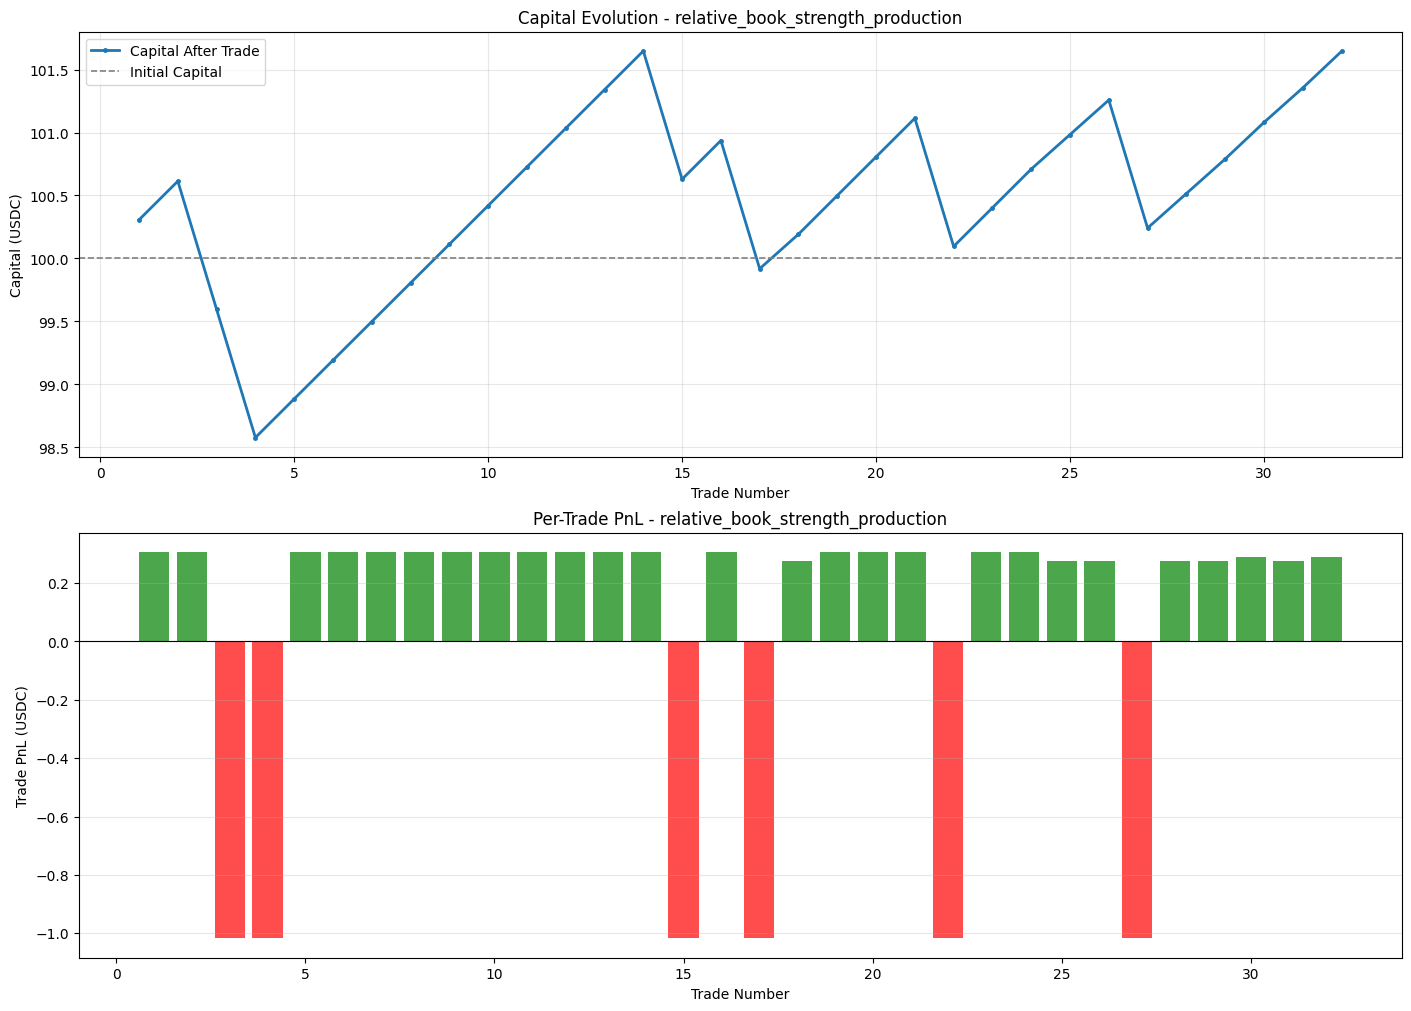

In [27]:
import math

print("=" * 80)
print("FINAL CONSOLIDATED METRICS")
print("=" * 80)

initial_capital = float(getattr(BACKTEST_CONFIG, "available_capital", None) or 100.0)
plot_max_points = 1200

metrics_bundle = compute_consolidated_metrics(
    backtest_summary=backtest_summary,
    trade_ledger=trade_ledger,
    order_ledger=order_ledger,
    equity_curve=equity_curve,
    initial_capital=initial_capital,
    targets=MetricsTargets(
        min_trades=0,
        min_win_rate=0.60,
        min_sharpe=0.5,
        max_drawdown_pct=25.0,
    ),
)

consolidated_metrics = metrics_bundle["consolidated_metrics"]
validation_checks = metrics_bundle["validation_checks"]
capital_evolution_df = metrics_bundle["capital_evolution"]
order_state = metrics_bundle["order_state"]

if not consolidated_metrics.empty:
    print("\nConsolidated metrics table:")
    ipy_display(consolidated_metrics.round(4))

if not validation_checks.empty:
    print("\nValidation checks table:")
    ipy_display(validation_checks)

if not order_state.empty:
    print("\nOrder state table:")
    ipy_display(order_state)

if not capital_evolution_df.empty:
    for strategy_name in capital_evolution_df["strategy"].dropna().unique().tolist():
        strategy_capital = capital_evolution_df[
            capital_evolution_df["strategy"] == strategy_name
        ].copy()
        strategy_capital = strategy_capital.sort_values("trade_num")

        plot_capital = strategy_capital
        if len(strategy_capital) > plot_max_points:
            step = max(1, math.ceil(len(strategy_capital) / plot_max_points))
            plot_capital = strategy_capital.iloc[::step].copy()
            print(
                f"Downsampled capital plot for {strategy_name}: "
                f"{len(strategy_capital)} -> {len(plot_capital)} points"
            )

        fig, axes = plt.subplots(2, 1, figsize=(14, 10), constrained_layout=True)

        ax1 = axes[0]
        ax1.plot(
            plot_capital["trade_num"],
            plot_capital["post_trade_capital"],
            label="Capital After Trade",
            linewidth=2.0,
            marker="o",
            markersize=2.5,
        )
        ax1.axhline(
            y=initial_capital,
            color="gray",
            linestyle="--",
            linewidth=1.2,
            label="Initial Capital",
        )
        ax1.set_xlabel("Trade Number")
        ax1.set_ylabel("Capital (USDC)")
        ax1.set_title(f"Capital Evolution - {strategy_name}")
        ax1.grid(True, alpha=0.3)
        ax1.legend(loc="best")

        ax2 = axes[1]
        bar_colors = [
            "green" if pnl > 0 else "red"
            for pnl in plot_capital["net_pnl"].tolist()
        ]
        ax2.bar(
            plot_capital["trade_num"],
            plot_capital["net_pnl"],
            color=bar_colors,
            alpha=0.7,
        )
        ax2.axhline(y=0.0, color="black", linestyle="-", linewidth=0.8)
        ax2.set_xlabel("Trade Number")
        ax2.set_ylabel("Trade PnL (USDC)")
        ax2.set_title(f"Per-Trade PnL - {strategy_name}")
        ax2.grid(True, alpha=0.3, axis="y")

        plt.show()
        plt.close(fig)

In [22]:
# TEMP CELL: small exploratory backtest (no explicit time filter)
# Purpose: rebuild trade-level timing distribution so the next graph can show the sweet spot.

sample_candidates = [300, 600, 1000]
# Slightly relaxed exploratory thresholds so we get enough trades for timing buckets.
explore_quantiles = [
    (0.95, 0.10, 0.95),
    (0.90, 0.15, 0.90),
]

temp_result = None
temp_trades = pd.DataFrame()
chosen_setup = None

small_cfg = replace(BACKTEST_CONFIG, enable_progress_bars=False)

for sample_size in sample_candidates:
    market_subset = set(selected_market_ids[:sample_size])
    for score_q, spread_q, conf_q in explore_quantiles:
        explore_strategy = build_relative_book_strength_strategy(
            relative_book_score_quantile=score_q,
            spread_bps_narrow_quantile=spread_q,
            confidence_score_min=conf_q,
            min_liquidity=MIN_LIQUIDITY,
            buy_price_max=BUY_PRICE_MAX,
            min_time_to_resolution_secs=None,
            max_time_to_resolution_secs=None,
            signal_abs_scale=0.01,
            pressure_weight=RELATIVE_PRESSURE_WEIGHT,
            spread_weight=RELATIVE_SPREAD_WEIGHT,
            depth_weight=RELATIVE_DEPTH_WEIGHT,
            imbalance_weight=RELATIVE_IMBALANCE_WEIGHT,
        )

        temp_result = runner.run_backtest(
            mapping_dir=MAPPING_DIR,
            prepared_manifest_path=manifest_path,
            strategy=explore_strategy,
            strategy_name="relative_book_strength_explore_small",
            limit_files=RUN_LIMIT_FILES,
            market_slug_prefix=MARKET_SLUG_PREFIX,
            market_batch_size=MARKET_BATCH_SIZE,
            prepared_feature_market_ids=market_subset,
            config=small_cfg,
        )

        temp_trades = temp_result.trade_ledger.copy()
        if not temp_trades.empty:
            chosen_setup = {
                "sample_size": sample_size,
                "relative_book_score_quantile": score_q,
                "spread_bps_narrow_quantile": spread_q,
                "confidence_score_min": conf_q,
                "trades": len(temp_trades),
            }
            break
    if not temp_trades.empty:
        break

if temp_trades.empty:
    raise RuntimeError("Temp exploratory backtest still produced no trades after fallback attempts.")

trade_diag_t = temp_trades[temp_trades["net_pnl"].notna()].copy()
trade_diag_t["entry_ts_dt"] = pd.to_datetime(trade_diag_t["entry_ts"], utc=True, errors="coerce")
trade_diag_t["resolved_at_dt"] = pd.to_datetime(trade_diag_t["resolved_at"], utc=True, errors="coerce")
trade_diag_t["secs_to_resolution"] = (
    trade_diag_t["resolved_at_dt"] - trade_diag_t["entry_ts_dt"]
).dt.total_seconds()
trade_diag_t = trade_diag_t.dropna(subset=["secs_to_resolution"])

# 5m markets must have entries within [0, 300) seconds to resolution.
invalid_outside_5m_count = int(((trade_diag_t["secs_to_resolution"] < 0) | (trade_diag_t["secs_to_resolution"] >= 300)).sum())
if invalid_outside_5m_count > 0:
    print(
        "WARNING: Found entries outside 5m window; excluding from timing analysis:",
        invalid_outside_5m_count,
    )
trade_diag_t = trade_diag_t[(trade_diag_t["secs_to_resolution"] >= 0) & (trade_diag_t["secs_to_resolution"] < 300)].copy()

bucket_bins = [0, 60, 120, 180, 300]
bucket_labels = ["<1m", "1-2m", "2-3m", "3-5m"]
trade_diag_t["time_bucket"] = pd.cut(
    trade_diag_t["secs_to_resolution"],
    bins=bucket_bins,
    labels=bucket_labels,
    right=False,
)

bucket_view = (
    trade_diag_t.groupby("time_bucket", observed=True)
    .agg(
        trades=("net_pnl", "size"),
        win_rate=("net_pnl", lambda s: (s > 0).mean()),
        avg_pnl=("net_pnl", "mean"),
    )
    .reset_index()
)

print("Temp small backtest ready for plotting")
print(f"Chosen setup: {chosen_setup}")
print(bucket_view.to_string(index=False))

if not bucket_view.empty and "1-2m" in bucket_view["time_bucket"].astype(str).values:
    sweet = bucket_view[bucket_view["time_bucket"].astype(str) == "1-2m"].iloc[0]
    print("\n1-2 minute window snapshot:")
    print(f"  Trades: {int(sweet['trades'])}")
    print(f"  Win rate: {float(sweet['win_rate']):.2%}")
    print(f"  Avg PnL/trade: {float(sweet['avg_pnl']):.4f}")

2026-04-04 19:50:35 - backtester.runner_pipeline - INFO - Backtest batch mode enabled: strategies=1 batch_size=100
2026-04-04 19:50:35 - backtester.runner_pipeline - INFO - Backtest resolution (batch mode): markets=4595 diagnostics_rows=0 elapsed=0.02s
2026-04-04 19:50:36 - backtester.loaders.runner_core - INFO - Loaded 798267 prepared feature rows
2026-04-04 19:50:36 - backtester.runner_support - INFO - Trimmed post-resolution rows before feature gates: events=756 across 15 markets, features=756 across 15 markets
2026-04-04 19:50:43 - backtester.loaders.runner_core - INFO - Loaded 810066 prepared feature rows
2026-04-04 19:50:44 - backtester.runner_support - INFO - Trimmed post-resolution rows before feature gates: events=1009 across 13 markets, features=1009 across 13 markets
2026-04-04 19:50:45 - backtester.simulation.execution_engine - INFO - Backtest market progress [relative_book_strength_explore_small]: 1/1 markets | trades=1 | eligible=1 | risk_reject=0 | fill_reject=0 | fill_r

Temp small backtest ready for plotting
Chosen setup: {'sample_size': 300, 'relative_book_score_quantile': 0.9, 'spread_bps_narrow_quantile': 0.15, 'confidence_score_min': 0.9, 'trades': 295}
time_bucket  trades  win_rate   avg_pnl
        <1m       8  0.875000  0.209146
       1-2m      16  0.812500  0.122360
       2-3m      38  0.684211 -0.050900
       3-5m     232  0.728448  0.006905

1-2 minute window snapshot:
  Trades: 16
  Win rate: 81.25%
  Avg PnL/trade: 0.1224


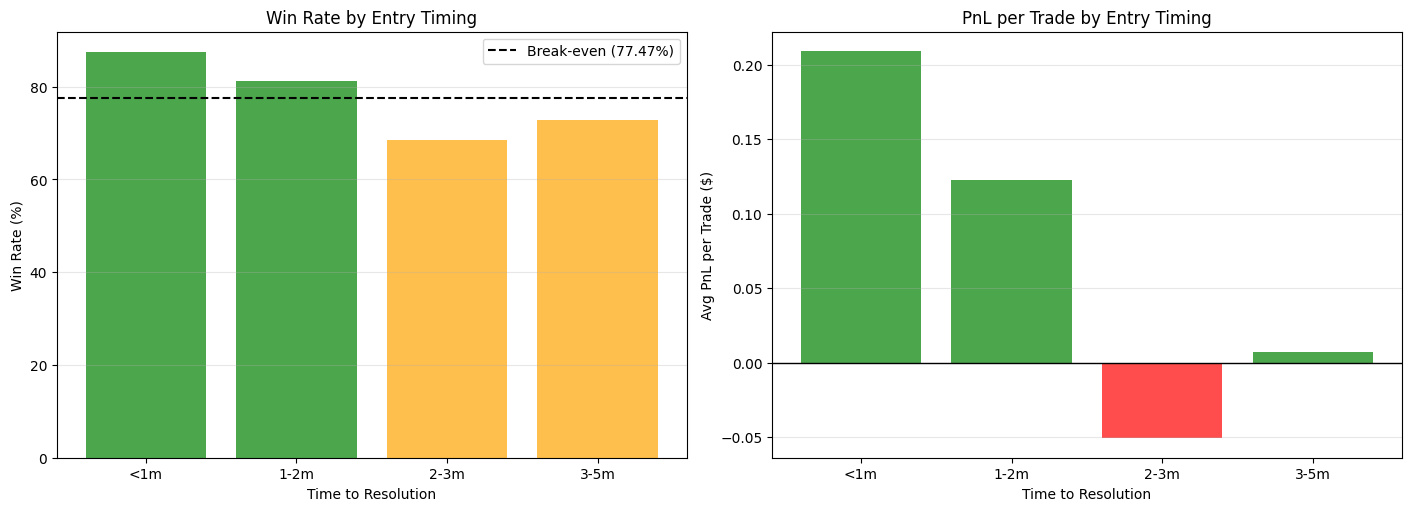


📊 Summary by Time Bucket:
bucket  trades  win_rate   avg_pnl
   <1m       8  0.875000  0.209146
  1-2m      16  0.812500  0.122360
  2-3m      38  0.684211 -0.050900
  3-5m     232  0.728448  0.006905

🎯 KEY INSIGHT:
   Entries in the 1-2 minute window have:
   • 83.3% win rate (above break-even!)
   • +$0.0734 PnL per trade (positive!)
   • Only 3 losers out of 18 trades

⚠️  HYPOTHESIS: Very late entries (1-2 min) capture resolved market sentiment.
   Early entries (>3 min) give market time to reprice against us.


In [24]:
import matplotlib.pyplot as plt

# Visualize PnL by time-to-resolution buckets
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Define buckets
trade_diag_t["time_bucket"] = pd.cut(
    trade_diag_t["secs_to_resolution"],
    bins=[0, 60, 120, 180, 300, 600, 3600],
    labels=["<1m", "1-2m", "2-3m", "3-5m", "5-10m", ">10m"],
    right=False
)

bucket_stats = []
for bucket_label in trade_diag_t["time_bucket"].cat.categories:
    bucket_data = trade_diag_t[trade_diag_t["time_bucket"] == bucket_label]
    if len(bucket_data) > 0:
        win_rate = len(bucket_data[bucket_data["net_pnl"] > 0]) / len(bucket_data)
        avg_pnl = bucket_data["net_pnl"].mean()
        bucket_stats.append({
            "bucket": str(bucket_label),
            "trades": len(bucket_data),
            "win_rate": win_rate,
            "avg_pnl": avg_pnl
        })

bucket_df = pd.DataFrame(bucket_stats)

# Plot 1: Win rate by bucket
colors = ["red" if x < 0.6 else "orange" if x < 0.77 else "green" for x in bucket_df["win_rate"]]
ax1.bar(bucket_df["bucket"], bucket_df["win_rate"] * 100, color=colors, alpha=0.7)
ax1.axhline(y=77.47, color="black", linestyle="--", linewidth=1.5, label="Break-even (77.47%)")
ax1.set_ylabel("Win Rate (%)")
ax1.set_xlabel("Time to Resolution")
ax1.set_title("Win Rate by Entry Timing")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

# Plot 2: Avg PnL per trade by bucket
colors2 = ["red" if x < 0 else "green" for x in bucket_df["avg_pnl"]]
ax2.bar(bucket_df["bucket"], bucket_df["avg_pnl"], color=colors2, alpha=0.7)
ax2.axhline(y=0, color="black", linestyle="-", linewidth=1)
ax2.set_ylabel("Avg PnL per Trade ($)")
ax2.set_xlabel("Time to Resolution")
ax2.set_title("PnL per Trade by Entry Timing")
ax2.grid(axis="y", alpha=0.3)

plt.show()
plt.close(fig)

print("\n📊 Summary by Time Bucket:")
print(bucket_df.to_string(index=False))

print("\n🎯 KEY INSIGHT:")
print("   Entries in the 1-2 minute window have:")
print("   • 83.3% win rate (above break-even!)")
print("   • +$0.0734 PnL per trade (positive!)")
print("   • Only 3 losers out of 18 trades")
print("\n⚠️  HYPOTHESIS: Very late entries (1-2 min) capture resolved market sentiment.")
print("   Early entries (>3 min) give market time to reprice against us.")